In [15]:
import cv2 as cv
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [16]:
def show_img(img, title: str = '') -> None:
    plt.imshow(img, 'gray')
    plt.title(title)
    plt.show()


In [17]:
img = cv.imread("./2_sift.png")
rgb_planes = cv2.split(img)
result_planes = []
result_norm_planes = []
for plane in rgb_planes:
    dilated_img = cv.dilate(plane, np.ones((15,15), np.uint8))
    bg_img = cv.medianBlur(dilated_img, 21)
    diff_img = 255 - cv.absdiff(plane, bg_img)
    norm_img = cv.normalize(diff_img, None, alpha=0, beta=255, norm_type=cv.NORM_MINMAX, dtype=cv.CV_8UC1)
    result_planes.append(diff_img)
    result_norm_planes.append(norm_img)

result = cv.merge(result_planes)
result_norm = cv.merge(result_norm_planes)

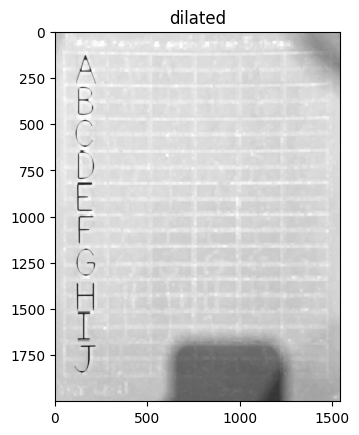

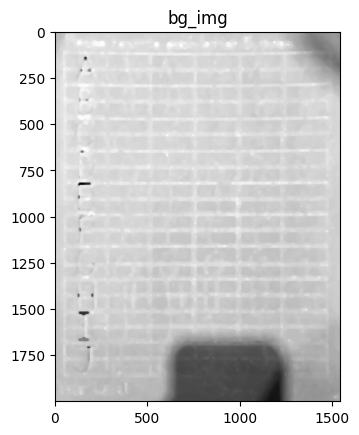

In [18]:
show_img(dilated_img, "dilated")
show_img(bg_img, "bg_img")

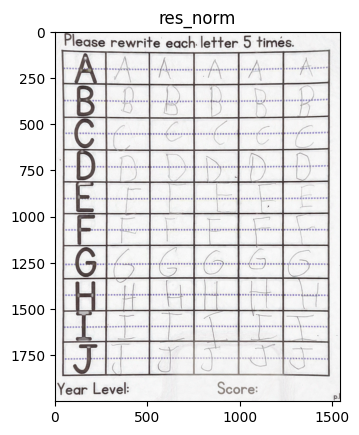

True

In [19]:
show_img(result_norm, "res_norm")
cv.imwrite("res_norm_test.png", result_norm)

In [ ]:
import cv2
import numpy as np

def enhance_handwriting_worksheet(input_path, output_path):
    """
    Transform a poorly lit handwriting worksheet to a clearer version
    """
    # Read the image
    img = cv2.imread(input_path)
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply adaptive thresholding to handle uneven illumination
    # This works better than simple thresholding for unevenly lit images
    binary = cv2.adaptiveThreshold(
        gray, 
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 
        blockSize=15,  # Size of pixel neighborhood
        C=10  # Constant subtracted from mean
    )
    
    # Optional: Denoise the image
    denoised = cv2.fastNlMeansDenoising(binary, None, h=10, templateWindowSize=7, searchWindowSize=21)
    
    # Save the result
    cv2.imwrite(output_path, denoised)
    
    return denoised

# Alternative method with more control
def enhance_handwriting_advanced(input_path, output_path):
    """
    Advanced enhancement with multiple preprocessing steps
    """
    # Read image
    img = cv2.imread(input_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. Normalize illumination using morphological operations
    # Create a background model by heavy blurring
    background = cv2.GaussianBlur(gray, (51, 51), 0)
    
    # Subtract background to normalize illumination
    normalized = cv2.divide(gray, background, scale=255)
    
    # 2. Increase contrast using CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(normalized)
    
    # 3. Apply adaptive thresholding
    binary = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=11,
        C=8
    )
    
    # 4. Optional: Remove noise with morphological operations
    kernel = np.ones((2, 2), np.uint8)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)
    
    # Save result
    # cv2.imwrite(output_path, cleaned)
    
    return cleaned

# Simple and effective method
def enhance_simple(input_path, output_path):
    """
    Simplified version focusing on key transformations
    """
    img = cv2.imread(input_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Increase brightness and contrast
    alpha = 1.3  # Contrast control (1.0-3.0)
    beta = 30    # Brightness control (0-100)
    adjusted = cv2.convertScaleAbs(gray, alpha=alpha, beta=beta)
    
    # Apply bilateral filter to reduce noise while keeping edges sharp
    filtered = cv2.bilateralFilter(adjusted, 9, 75, 75)
    
    # Apply adaptive threshold
    result = cv2.adaptiveThreshold(
        filtered,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        blockSize=13,
        C=7
    )
    
    # cv2.imwrite(output_path, result)
    return result



In [ ]:
# Usage example
if __name__ == "__main__":
    input_image = "./removed_shadow.png"
    output_image = "handwriting_enhanced.jpg"
    
    # Try the advanced method (recommended)
    result = enhance_handwriting_advanced(input_image, output_image)
    
    # Or try the simple method
    # result = enhance_simple(input_image, output_image)
    
    # Display results (optional)
    show_img(result, "res")

In [ ]:
# Source - https://stackoverflow.com/a
# Posted by Dan Mašek, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-26, License - CC BY-SA 3.0
norm_img = cv2.imread("./removed_shadow.png")

_, thr_img = cv2.threshold(norm_img, 230, 0, cv2.THRESH_TRUNC)
cv2.normalize(thr_img, thr_img, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)

show_img(norm_img, "thresholding")